In [29]:
from google.colab import files

# Upload your kaggle.json when the picker appears
files.upload()

import os
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
os.rename('/content/kaggle_1.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

print("Kaggle configured")

Saving kaggle_1.json to kaggle_1.json
Kaggle configured


In [30]:
!kaggle datasets download \
    -d cynthiarempel/amazon-us-customer-reviews-dataset \
    -f amazon_reviews_us_Electronics_v1_00.tsv \
    -p /content/drive/MyDrive/opinionx/data/raw/ \
    --unzip

print("Done — file saved to Drive")

Dataset URL: https://www.kaggle.com/datasets/cynthiarempel/amazon-us-customer-reviews-dataset
License(s): other
100% 675M/675M [00:10<00:00, 70.5MB/s]

Done — file saved to Drive


In [35]:
BASE = '/content/drive/MyDrive/opinionx'
DATA_PATH = f'{BASE}/data/raw/amazon_reviews_us_Electronics_v1_00.tsv.zip'
PROCESSED_PATH = f'{BASE}/data/processed'
SAMPLE_PATH = f'{BASE}/data/sample'

print("Paths set")

Paths set


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print("All imports OK")

All imports OK


In [37]:
print("Loading dataset...")

df = pd.read_csv(
    DATA_PATH,
    sep='\t',
    nrows=100_000,
    on_bad_lines='skip',
    low_memory=False
)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Loading dataset...
Shape: (100000, 15)
Columns: ['marketplace', 'customer_id', 'review_id', 'product_id', 'product_parent', 'product_title', 'product_category', 'star_rating', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_headline', 'review_body', 'review_date']


,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,US,41409413,R2MTG1GCZLR2DK,B00428R89M,112201306,yoomall 5M Antenna WIFI RP-SMA Female to Male ...,Electronics,5,0,0,N,Y,Five Stars,As described.,2015-08-31
1,US,49668221,R2HBOEM8LE9928,B000068O48,734576678,"Hosa GPM-103 3.5mm TRS to 1/4"" TRS Adaptor",Electronics,5,0,0,N,Y,It works as advertising.,It works as advertising.,2015-08-31
2,US,12338275,R1P4RW1R9FDPEE,B000GGKOG8,614448099,Channel Master Titan 2 Antenna Preamplifier,Electronics,5,1,1,N,Y,Five Stars,Works pissa,2015-08-31


In [38]:
print("=== DATASET INFO ===")
print(f"Total reviews: {len(df):,}")
print(f"\nColumn types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

=== DATASET INFO ===
Total reviews: 100,000

Column types:
marketplace          object
customer_id           int64
review_id            object
product_id           object
product_parent        int64
product_title        object
product_category     object
star_rating           int64
helpful_votes         int64
total_votes           int64
vine                 object
verified_purchase    object
review_headline      object
review_body          object
review_date          object
dtype: object

Missing values:
marketplace           0
customer_id           0
review_id             0
product_id            0
product_parent        0
product_title         0
product_category      0
star_rating           0
helpful_votes         0
total_votes           0
vine                  0
verified_purchase     0
review_headline       0
review_body          18
review_date           0
dtype: int64


In [39]:
# Keep only relevant columns
cols = [
    'star_rating',
    'helpful_votes',
    'total_votes',
    'vine',
    'verified_purchase',
    'review_headline',
    'review_body',
    'product_title',
    'product_category'
]

df = df[cols].copy()

# Fix star_rating — sometimes loads as string
df['star_rating'] = pd.to_numeric(df['star_rating'], errors='coerce')

# Drop rows with no review text or no rating
df.dropna(subset=['review_body', 'star_rating'], inplace=True)

print(f"Shape after cleanup: {df.shape}")
df.head(3)

Shape after cleanup: (99982, 9)


,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,product_title,product_category
0,5,0,0,N,Y,Five Stars,As described.,yoomall 5M Antenna WIFI RP-SMA Female to Male ...,Electronics
1,5,0,0,N,Y,It works as advertising.,It works as advertising.,"Hosa GPM-103 3.5mm TRS to 1/4"" TRS Adaptor",Electronics
2,5,1,1,N,Y,Five Stars,Works pissa,Channel Master Titan 2 Antenna Preamplifier,Electronics


In [40]:
# Convert star ratings to binary sentiment
# Drop 3-star reviews (neutral/ambiguous)
df = df[df['star_rating'] != 3].copy()

df['sentiment'] = df['star_rating'].apply(
    lambda x: 'positive' if x >= 4 else 'negative'
)
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("Label distribution:")
print(df['sentiment'].value_counts())
print(f"\nPositive: {(df['label']==1).sum():,}")
print(f"Negative: {(df['label']==0).sum():,}")

Label distribution:
sentiment
positive    76328
negative    16790
Name: count, dtype: int64

Positive: 76,328
Negative: 16,790


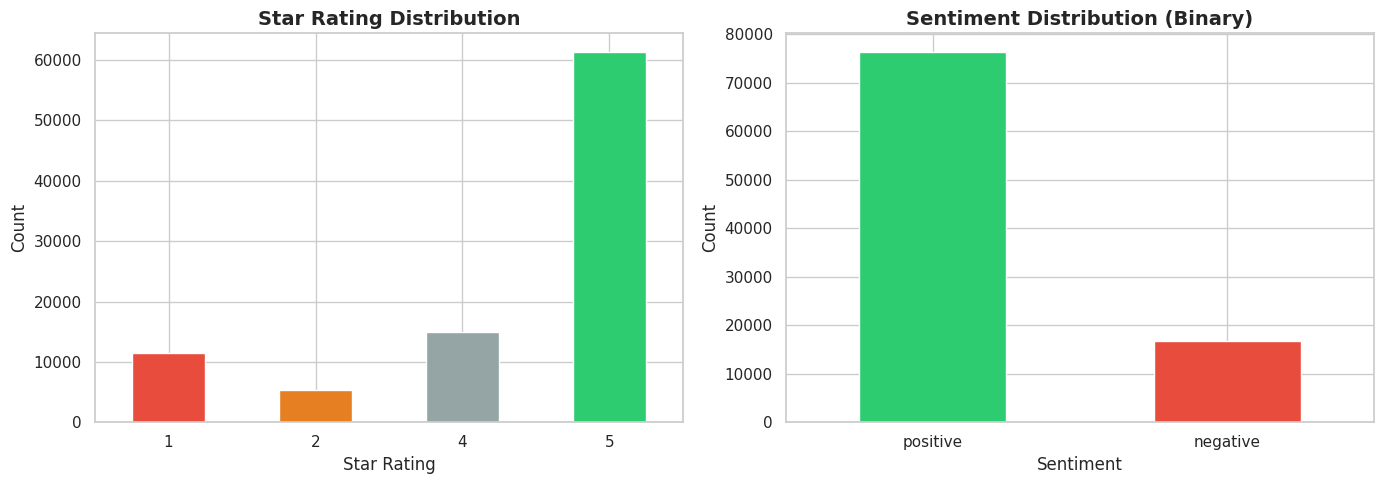

Chart saved


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Star rating distribution
df['star_rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#e74c3c','#e67e22','#95a5a6','#2ecc71','#27ae60'],
    edgecolor='white'
)
axes[0].set_title('Star Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Sentiment distribution
df['sentiment'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white'
)
axes[1].set_title('Sentiment Distribution (Binary)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig(f'{BASE}/outputs/plots/01_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

Review length stats:
             count  mean   std  min   25%   50%   75%     max
sentiment                                                    
negative   16790.0  45.8  75.3  1.0  11.0  25.0  54.0  2719.0
positive   76328.0  38.5  96.0  1.0   5.0  14.0  38.0  7501.0


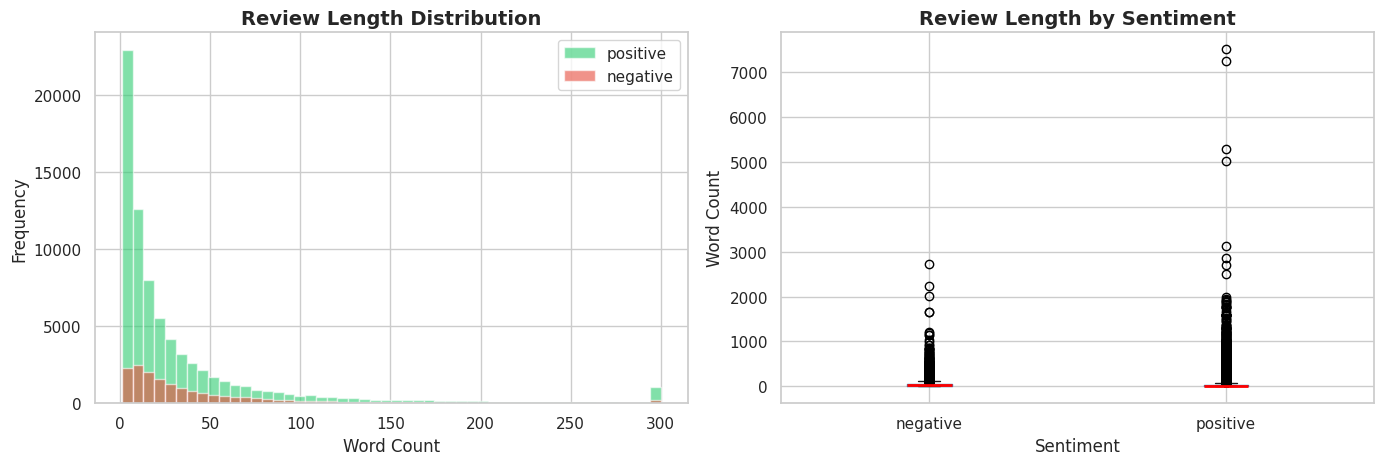

In [42]:
# Add review length column
df['review_length'] = df['review_body'].astype(str).apply(lambda x: len(x.split()))

print("Review length stats:")
print(df.groupby('sentiment')['review_length'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for sentiment, color in [('positive', '#2ecc71'), ('negative', '#e74c3c')]:
    subset = df[df['sentiment'] == sentiment]['review_length']
    axes[0].hist(subset.clip(upper=300), bins=50, alpha=0.6,
                 color=color, label=sentiment, edgecolor='white')

axes[0].set_title('Review Length Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot
df.boxplot(column='review_length', by='sentiment', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Review Length by Sentiment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.savefig(f'{BASE}/outputs/plots/02_review_length.png', dpi=150, bbox_inches='tight')
plt.show()

Helpfulness ratio by sentiment:
             count   mean    std  min  25%  50%  75%  max
sentiment                                                
negative   16790.0  0.239  0.394  0.0  0.0  0.0  0.5  1.0
positive   76328.0  0.144  0.339  0.0  0.0  0.0  0.0  1.0


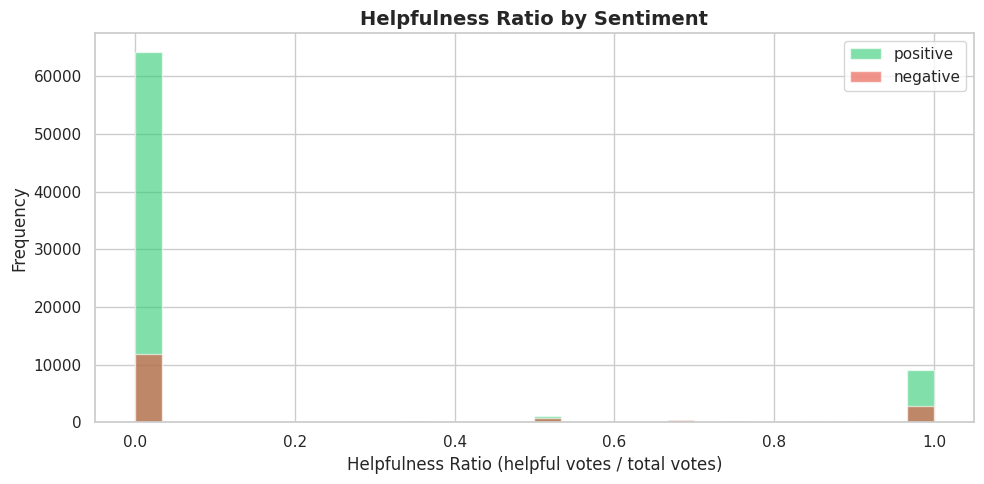

In [43]:
df['helpful_votes'] = pd.to_numeric(df['helpful_votes'], errors='coerce').fillna(0)
df['total_votes'] = pd.to_numeric(df['total_votes'], errors='coerce').fillna(0)

# Helpfulness ratio — this becomes your trust signal
df['helpfulness_ratio'] = df.apply(
    lambda row: row['helpful_votes'] / row['total_votes']
    if row['total_votes'] > 0 else 0, axis=1
)

print("Helpfulness ratio by sentiment:")
print(df.groupby('sentiment')['helpfulness_ratio'].describe().round(3))

fig, ax = plt.subplots(figsize=(10, 5))
for sentiment, color in [('positive', '#2ecc71'), ('negative', '#e74c3c')]:
    subset = df[df['sentiment'] == sentiment]['helpfulness_ratio']
    ax.hist(subset, bins=30, alpha=0.6, color=color,
            label=sentiment, edgecolor='white')

ax.set_title('Helpfulness Ratio by Sentiment', fontsize=14, fontweight='bold')
ax.set_xlabel('Helpfulness Ratio (helpful votes / total votes)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/plots/03_helpfulness.png', dpi=150, bbox_inches='tight')
plt.show()

Verified purchase vs sentiment:
sentiment          negative  positive
verified_purchase                    
N                      1545      6166
Y                     15245     70162


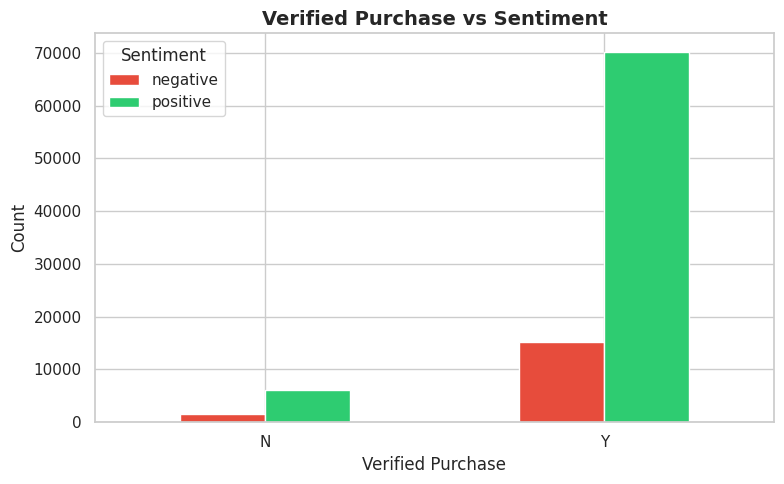

In [44]:
df['verified_purchase'] = df['verified_purchase'].astype(str).str.strip().str.upper()

verified_sentiment = df.groupby(['verified_purchase', 'sentiment']).size().unstack(fill_value=0)
print("Verified purchase vs sentiment:")
print(verified_sentiment)

verified_sentiment.plot(
    kind='bar',
    color=['#e74c3c', '#2ecc71'],
    edgecolor='white',
    figsize=(8, 5)
)
plt.title('Verified Purchase vs Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Verified Purchase')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/plots/04_verified_purchase.png', dpi=150, bbox_inches='tight')
plt.show()

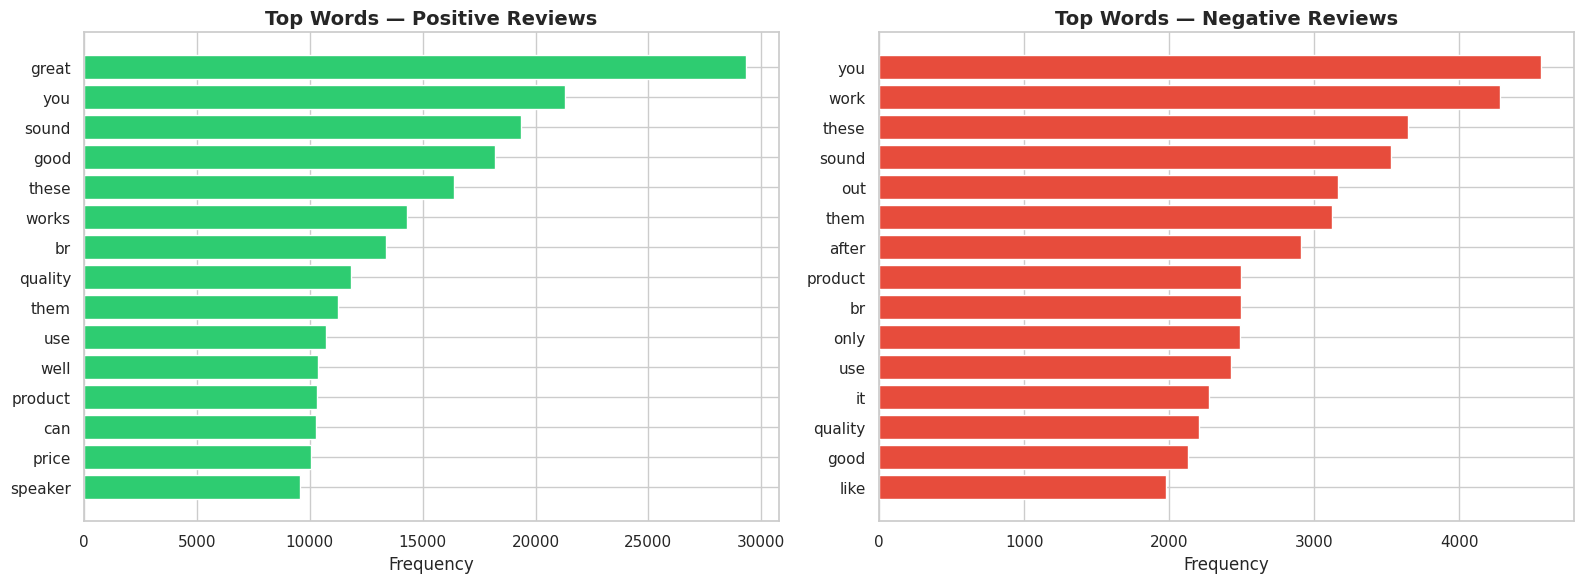

In [45]:
from collections import Counter

# Simple stopwords
STOPWORDS = {
    'the','a','an','and','or','but','in','on','at','to','for',
    'of','with','is','was','it','this','that','i','my','we',
    'they','he','she','have','had','be','are','not','so','as',
    'just','its','very','get','got','from','would','could','one',
    'also','all','more','been','has','will','when','if','but','up'
}

def top_words(texts, n=15):
    words = []
    for text in texts.astype(str):
        words.extend([
            w.lower().strip(string.punctuation)
            for w in text.split()
            if w.lower() not in STOPWORDS and len(w) > 2
        ])
    return Counter(words).most_common(n)

pos_words = top_words(df[df['sentiment']=='positive']['review_body'])
neg_words = top_words(df[df['sentiment']=='negative']['review_body'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive words
words, counts = zip(*pos_words)
axes[0].barh(words[::-1], counts[::-1], color='#2ecc71', edgecolor='white')
axes[0].set_title('Top Words — Positive Reviews', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency')

# Negative words
words, counts = zip(*neg_words)
axes[1].barh(words[::-1], counts[::-1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Top Words — Negative Reviews', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig(f'{BASE}/outputs/plots/05_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
import re
import string

def preprocess_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove digits
    text = re.sub(r'\d+', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Test it
sample = df['review_body'].iloc[0]
print("Original:", sample[:200])
print("\nCleaned:", preprocess_text(sample)[:200])

Original: As described.

Cleaned: as described


In [47]:
print("Preprocessing review text...")
df['clean_text'] = df['review_body'].apply(preprocess_text)

# Also clean headline
df['clean_headline'] = df['review_headline'].apply(preprocess_text)

# Combine headline + body for richer text signal
df['full_text'] = df['clean_headline'] + ' ' + df['clean_text']

# Remove empty reviews after cleaning
df = df[df['clean_text'].str.split().str.len() >= 5]

print(f"Shape after preprocessing: {df.shape}")
df[['review_body', 'clean_text', 'sentiment']].head(3)

Preprocessing review text...
Shape after preprocessing: (74938, 16)


,review_body,clean_text,sentiment
3,Did not work at all.,did not work at all,negative
4,Works well. Bass is somewhat lacking but is pr...,works well bass is somewhat lacking but is pre...,positive
5,The quality on these speakers is insanely good...,the quality on these speakers is insanely good...,positive


In [48]:
import os
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(SAMPLE_PATH, exist_ok=True)

# Save full processed dataset
df.to_csv(f'{PROCESSED_PATH}/reviews_clean.csv', index=False)
print(f"Saved full processed: {len(df):,} reviews")

# Save stratified 50k sample for baseline models
sample_50k = df.groupby('sentiment', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 25_000), random_state=42)
).reset_index(drop=True)

sample_50k.to_csv(f'{SAMPLE_PATH}/sample_50k.csv', index=False)
print(f"Saved 50k sample: {len(sample_50k):,} reviews")

# Save small 5k sample for fast testing
sample_5k = df.groupby('sentiment', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 2_500), random_state=42)
).reset_index(drop=True)

sample_5k.to_csv(f'{SAMPLE_PATH}/sample_5k.csv', index=False)
print(f"Saved 5k sample: {len(sample_5k):,} reviews")

print("\nAll files saved to Drive")

Saved full processed: 74,938 reviews
Saved 50k sample: 40,379 reviews
Saved 5k sample: 5,000 reviews

All files saved to Drive


In [49]:
print("=" * 50)
print("DATASET SUMMARY — for report")
print("=" * 50)
print(f"Total reviews loaded:     {len(df):,}")
print(f"Positive reviews:         {(df['label']==1).sum():,} ({(df['label']==1).mean()*100:.1f}%)")
print(f"Negative reviews:         {(df['label']==0).sum():,} ({(df['label']==0).mean()*100:.1f}%)")
print(f"Avg review length:        {df['review_length'].mean():.0f} words")
print(f"Verified purchases:       {(df['verified_purchase']=='Y').sum():,}")
print(f"Reviews with votes:       {(df['total_votes']>0).sum():,}")
print(f"Avg helpfulness ratio:    {df['helpfulness_ratio'].mean():.3f}")
print("=" * 50)

DATASET SUMMARY — for report
Total reviews loaded:     74,938
Positive reviews:         59,559 (79.5%)
Negative reviews:         15,379 (20.5%)
Avg review length:        49 words
Verified purchases:       67,651
Reviews with votes:       20,374
Avg helpfulness ratio:    0.186
